In [298]:
import pandas as pd
import numpy as np
from bs4 import BeautifulSoup
from nltk.stem import PorterStemmer
import re
import nltk
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from fuzzywuzzy import fuzz
import string
from collections import Counter
from nltk import bigrams
from nltk.util import trigrams
import spacy
from tqdm import tqdm
from nltk.tokenize import word_tokenize
import xgboost
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, log_loss
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sentence_transformers import SentenceTransformer
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
import tensorflow as tf
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
import plotly.express as px
from pandasql import sqldf

In [3]:
quora=pd.read_csv("quora.csv",sep=",")
quora

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0
...,...,...,...,...,...,...
404285,404285,433578,379845,How many keywords are there in the Racket prog...,How many keywords are there in PERL Programmin...,0
404286,404286,18840,155606,Do you believe there is life after death?,Is it true that there is life after death?,1
404287,404287,537928,537929,What is one coin?,What's this coin?,0
404288,404288,537930,537931,What is the approx annual cost of living while...,I am having little hairfall problem but I want...,0


## 1.Exploratory Data Analysis

In [5]:
quora.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404290 entries, 0 to 404289
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            404290 non-null  int64 
 1   qid1          404290 non-null  int64 
 2   qid2          404290 non-null  int64 
 3   question1     404289 non-null  object
 4   question2     404288 non-null  object
 5   is_duplicate  404290 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 18.5+ MB


In [306]:
dupes_count=quora["is_duplicate"].value_counts().reset_index()
dupes_count

,is_duplicate,count
0,0,255027
1,1,149263


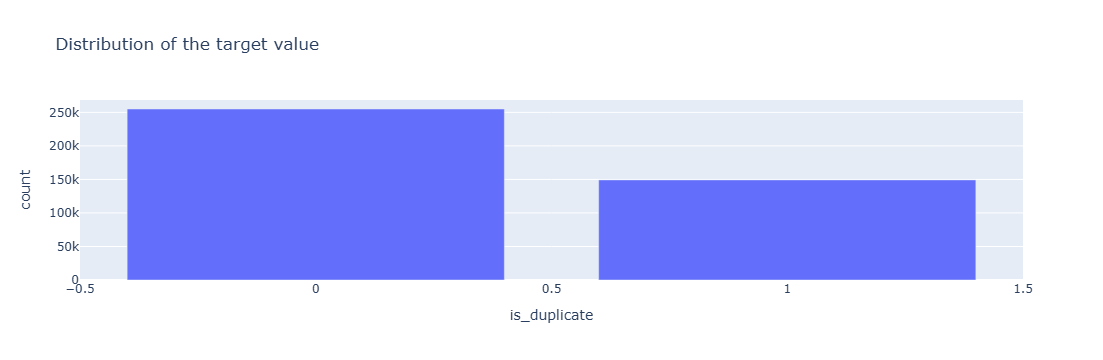

In [328]:
fig=px.bar(dupes_count,x="is_duplicate",y="count",title="Distribution of the target value",height=600)
fig.show()

In [8]:
print(quora[quora.isna().any(axis=1)])

            id    qid1    qid2                         question1  \
105780  105780  174363  174364    How can I develop android app?   
201841  201841  303951  174364  How can I create an Android app?   
363362  363362  493340  493341                               NaN   

                                                question2  is_duplicate  
105780                                                NaN             0  
201841                                                NaN             0  
363362  My Chinese name is Haichao Yu. What English na...             0  


In [10]:
quora=quora.fillna("")

In [12]:
x=pd.concat([quora["question1"],quora["question2"]],axis=1)
y=quora["is_duplicate"]

In [14]:
print(x.isnull().sum())
y.info()

question1    0
question2    0
dtype: int64
<class 'pandas.core.series.Series'>
RangeIndex: 404290 entries, 0 to 404289
Series name: is_duplicate
Non-Null Count   Dtype
--------------   -----
404290 non-null  int64
dtypes: int64(1)
memory usage: 3.1 MB


## 2.Basic Feature Extraction
1.__q1len__:The number of characters each question from question 1 has.\
2.__q2len__:The number of characters each question from question 2 has.\
3.__q1_word_count__:The number of words each question from question 1 has.\
4.__q2_word_count__:The number of words each question from question 2 has.\
5.__char_count_diff__:The absolute difference of the number of characters for each pair of questions.\
6.__word_count_diff__:The absolute difference of the number of words for each pair of questions.\
7.__common_words__:The number of common words for each pair of questions.\
8.__common_bigrams__:The number of common bigrams for each pair of questions.\
9.__common_trigrams__:The number of common trigrams for each pair of questions.\
10.__percentage_of_common_words__:The percentage of the number of common words for each pair of questions.

In [17]:
x["q1len"]=x["question1"].str.len()
x["q2len"]=x["question2"].str.len()
x["q1_word_count"]=x["question1"].apply(lambda text:len(text.split(" ")))
x["q2_word_count"]=x["question2"].apply(lambda text:len(text.split(" ")))
x["char_count_diff"]=abs(x["q1len"]-x["q2len"])
x["word_count_diff"]=abs(x["q1_word_count"]-x["q2_word_count"])

In [18]:
def common_words(row):
 w1=set(map(lambda word: word.lower().strip(), row['question1'].split(" ")))
 w2=set(map(lambda word:word.lower().strip(), row["question2"].split(" ")))
 return len(w1 & w2)    

In [21]:
x["common_words"]=x.apply(common_words,axis=1)

In [22]:
def common_bigrams(row):
    w1=map(lambda word: word.lower().strip(), row['question1'].split(" "))
    w2=map(lambda word:word.lower().strip(), row["question2"].split(" "))
    count1=Counter(bigrams(w1))
    count2=Counter(bigrams(w2))
    
    return len(count1&count2)

In [23]:
def common_trigrams(row):
    w1=map(lambda word: word.lower().strip(), row['question1'].split(" "))
    w2=map(lambda word:word.lower().strip(), row["question2"].split(" "))
    count1=Counter(trigrams(w1))
    count2=Counter(trigrams(w2))
    
    return len(count1&count2)

In [24]:
def percentage_of_common_words(row):
     w1 = set(map(lambda word: word.lower().strip(), row['question1'].split(" ")))
     w2 = set(map(lambda word: word.lower().strip(), row['question2'].split(" ")))
     return len(w1&w2)/(len(w1)+len(w2))

In [25]:
x["common_bigrams"]=x.apply(common_bigrams,axis=1)
x["common_trigrams"]=x.apply(common_trigrams,axis=1)
x["percentage_of_common_words"]=x.apply(percentage_of_common_words,axis=1)    

In [30]:
x

,question1,question2,q1len,q2len,q1_word_count,q2_word_count,char_count_diff,word_count_diff,common_words,common_bigrams,common_trigrams,percentage_of_common_words
0,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,66,57,14,12,9,2,10,10,9,0.434783
1,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,51,88,8,13,37,5,4,1,0,0.200000
2,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,73,59,14,10,14,4,4,1,0,0.166667
3,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,50,65,11,9,15,2,0,0,0,0.000000
4,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,76,39,13,7,37,6,2,0,0,0.100000
...,...,...,...,...,...,...,...,...,...,...,...,...
404285,How many keywords are there in the Racket prog...,How many keywords are there in PERL Programmin...,85,79,14,13,6,1,11,9,5,0.440000
404286,Do you believe there is life after death?,Is it true that there is life after death?,41,42,8,9,1,1,5,4,3,0.312500
404287,What is one coin?,What's this coin?,17,17,4,3,0,1,1,0,0,0.142857
404288,What is the approx annual cost of living while...,I am having little hairfall problem but I want...,94,127,17,25,33,8,1,0,0,0.025000


## 3.Text preprocessing
First,we are lowercasing the text,we standardize some words,removed emoticons,removed some stopwords that we think do not affect the classification of the questions,we performed stemming,removed punctuation,removed blank space and removed any html/xml tags

In [34]:
def preprocessor(x):
    # Lowercasing
    processed_doc = str(x).lower()
    
    # Replace specific strings with their expanded versions
    processed_doc= x.replace(",000,000", "m").replace(",000", "k").replace("′", "'").replace("’", "'")\
                           .replace("won't", "will not").replace("cannot", "can not").replace("can't", "can not")\
                           .replace("n't", " not").replace("what's", "what is").replace("it's", "it is")\
                           .replace("'ve", " have").replace("i'm", "i am").replace("'re", " are")\
                           .replace("he's", "he is").replace("she's", "she is").replace("'s", " own")\
                           .replace("%", " percent ").replace("₹", " rupee ").replace("$", " dollar ")\
                           .replace("€", " euro ").replace("'ll", " will")
    emoticons = re.findall('(?::|;|=)(?:-)?(?:)|(|D|P)', x)
    processed_doc = (re.sub('[\W]+'," ",' '.join(emoticons).replace('-', '')))
    stopwords = ['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', 'your', 'yours',
                'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', 'her', 'hers',
                'herself', 'it', 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves',
                'this', 'that', 'these', 'those', 'am', 'are',
                "be",'been', 'being', 'had','doing', 'a', 'an', 'the', 'and', 'but', 'or', 'because', 'as', 'until',
                'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into',
                'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down',
                'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once', 'here',
                'there', 'all', 'any', 'both', 'each', 'few', 'more',
                'most', 'other', 'some', 'such', 'no', 'nor', 'not', 'only', 'so', 
                'too', 'very', 's', 't', 'just', 'don', "now","br"]
    
     # Replace numbers ending in "000" or "000,000" with "k" or "m" respectively
    processed_doc = re.sub(r"([0-9]+)000000", r"\1m", x)
    processed_doc = re.sub(r"([0-9]+)000", r"\1k", x)
    
    
    porter = PorterStemmer()
    punctuation = set(string.punctuation)
    processed_doc=porter.stem(x)
    processed_doc = ''.join([w if w not in punctuation else ' ' for w in x.lower()])
    processed_doc = [w for w in processed_doc.split() if w not in stopwords]
    processed_doc = ' '.join(w for w in processed_doc)
    
    
    
    # Remove non-alphanumeric characters
    pattern = re.compile('\W') # pattern that matches all non-alphanumeric characters
    if type(x) == type(''): # checks if the data type of x is a string 
        x = re.sub(pattern, ' ', x)
    
    if type(x) == type(''):
        example1 = BeautifulSoup(x)
        x = example1.get_text() #  returns a string containing only the text content of the HTML/XML document Any HTML/XML tags or attributes are removed, leaving only the plain text content.
    
    return processed_doc



<>:14: SyntaxWarning: invalid escape sequence '\W'
<>:42: SyntaxWarning: invalid escape sequence '\W'
<>:14: SyntaxWarning: invalid escape sequence '\W'
<>:42: SyntaxWarning: invalid escape sequence '\W'
C:\Users\giorg\AppData\Local\Temp\ipykernel_16136\167142250.py:14: SyntaxWarning: invalid escape sequence '\W'
  processed_doc = (re.sub('[\W]+'," ",' '.join(emoticons).replace('-', '')))
C:\Users\giorg\AppData\Local\Temp\ipykernel_16136\167142250.py:42: SyntaxWarning: invalid escape sequence '\W'
  pattern = re.compile('\W') # pattern that matches all non-alphanumeric characters


In [36]:
q1_processed=x["question1"].apply(preprocessor)
q2_processed=x["question2"].apply(preprocessor)
x_processed=pd.concat([q1_processed,q2_processed],axis=1)
x_processed

,question1,question2
0,what is step step guide invest share market india,what is step step guide invest share market
1,what is story kohinoor koh noor diamond,what would happen if indian government stole k...
2,how can increase speed internet connection usi...,how can internet speed increased hacking dns
3,why mentally lonely how can solve,find remainder when math 23 24 math is divided...
4,which one dissolve water quikly sugar salt met...,which fish would survive salt water
...,...,...
404285,how many keywords racket programming language ...,how many keywords perl programming language la...
404286,do believe is life death,is true is life death
404287,what is one coin,what coin
404288,what is approx annual cost living studying uic...,having little hairfall problem want use hair s...


## 4.Advanced Features
### 4.1.Fuzzy Features

In accordance with FuzzyWuzzy, TheFuzz uses the Levenshtein edit distance (https://en.wikipedia.org/wiki/Levenshtein_distance) to calculate the degree of closeness between two strings. It also provides features for determining string similarity in various situations.\
The __ratio()__ simply calculates the edit distance based on the ordering of both input strings difflib.ratio().https://docs.python.org/2/library/difflib.html#difflib.SequenceMatcher.ratio \
The __partial_ratio()__ seeks to find how partially similar two strings are. Two strings are partially similar if they have some of the words in a common order.\
The __token_set_ratio()__ method is pretty similar to the token_sort_ratio(), except it takes out common tokens before calculating how similar the strings are.\
__token_sort_ratio()__ accounts for similar strings that aren’t in order.

In [40]:
x["fuzz_ratio"]=x_processed.apply(lambda x:fuzz.ratio(x["question1"],x["question2"]),axis=1)
x["partial_fuzz_ratio"]=x_processed.apply(lambda x: fuzz.partial_ratio(x["question1"], x["question2"]), axis=1)
x["token_set_ratio"]=x_processed.apply(lambda x:fuzz.token_set_ratio(x["question1"], x["question2"]), axis=1)
x["token_sort_ratio"]=x_processed.apply(lambda x: fuzz.token_sort_ratio(x["question1"], x["question2"]), axis=1)

### 4.2.More Features
__first_word_match__:Returns 1 if the first word for a pair of questions is the same else it returns 0.\
__last_word_match__:Returns 1 if the last word for a pair of questions is the same else it returns 0.\
__jaccard_similarity__:Computes the jaccard similarity

In [42]:
def first_word_match(q1, q2): #check if the first words of the two questions are the same
    w1, w2 = q1.split(" "), q2.split(" ")
    return int(w1[0] == w2[0]) if w1 and w2 else 0
def last_word_match(q1,q2):
    w1,w2=q1.split(" "),q2.split(" ")
    return int(w1[-1]==w2[-1]) if w1 and w2 else 0
def jaccard_similarity(q1, q2): #how much the two sets of words overlap
    w1, w2 = set(q1.split()), set(q2.split())
    return len(w1 & w2) / len(w1 | w2) if w1 | w2 else 0

## 4.3.Sentence Transormers
We used a pretrained Bert model to get text embeddings and calculate the cosine similarity of them.

In [46]:
model = SentenceTransformer('all-MiniLM-L6-v2') #load a pre-trained Sentence-BERT model

q1_list = x_processed['question1'].tolist() #convert cleaned question 1 into a list
q2_list = x_processed['question2'].tolist() #convert cleaned question 2 into a list

#generate sentence embeddings for both questions
q1_embeddings = model.encode(q1_list, convert_to_tensor=False)
q2_embeddings = model.encode(q2_list, convert_to_tensor=False)

#compute cosine similarity between each pair of embeddings
semantic_sim = [
    cosine_similarity([q1], [q2])[0][0] for q1, q2 in tqdm(zip(q1_embeddings, q2_embeddings))
]

#add the semantic similarity as a new feature column
x['semantic_similarity'] = semantic_sim

404290it [02:20, 2872.42it/s]


In [48]:
x["first_word_match"] = x_processed.apply(lambda row: first_word_match(row["question1"], row["question2"]), axis=1)
x["last_word_match"] = x_processed.apply(lambda row: last_word_match(row["question1"], row["question2"]), axis=1)
x["jaccard_similarity"] = x_processed.apply(lambda row: jaccard_similarity(row["question1"], row["question2"]), axis=1)

In [49]:
features=x.iloc[:,2:]
features

,q1len,q2len,q1_word_count,q2_word_count,char_count_diff,word_count_diff,common_words,common_bigrams,common_trigrams,percentage_of_common_words,fuzz_ratio,partial_fuzz_ratio,token_set_ratio,token_sort_ratio,semantic_similarity,first_word_match,last_word_match,jaccard_similarity
0,66,57,14,12,9,2,10,10,9,0.434783,93,100,100,93,0.926565,1,0,0.875000
1,51,88,8,13,37,5,4,1,0,0.200000,63,79,87,63,0.633049,1,0,0.357143
2,73,59,14,10,14,4,4,1,0,0.166667,62,64,75,75,0.450359,1,0,0.363636
3,50,65,11,9,15,2,0,0,0,0.000000,31,39,30,28,0.180306,0,0,0.000000
4,76,39,13,7,37,6,2,0,0,0.100000,50,51,63,48,0.222867,1,0,0.214286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
404285,85,79,14,13,6,1,11,9,5,0.440000,93,91,95,90,0.599972,1,1,0.777778
404286,41,42,8,9,1,1,5,4,3,0.312500,71,76,84,62,0.822998,0,1,0.500000
404287,17,17,4,3,0,1,1,0,0,0.142857,72,67,100,72,0.713088,1,1,0.500000
404288,94,127,17,25,33,8,1,0,0,0.025000,45,51,41,41,-0.025521,0,0,0.000000


In [52]:
X=pd.concat([x_processed,features],axis=1)
X

,question1,question2,q1len,q2len,q1_word_count,q2_word_count,char_count_diff,word_count_diff,common_words,common_bigrams,common_trigrams,percentage_of_common_words,fuzz_ratio,partial_fuzz_ratio,token_set_ratio,token_sort_ratio,semantic_similarity,first_word_match,last_word_match,jaccard_similarity
0,what is step step guide invest share market india,what is step step guide invest share market,66,57,14,12,9,2,10,10,9,0.434783,93,100,100,93,0.926565,1,0,0.875000
1,what is story kohinoor koh noor diamond,what would happen if indian government stole k...,51,88,8,13,37,5,4,1,0,0.200000,63,79,87,63,0.633049,1,0,0.357143
2,how can increase speed internet connection usi...,how can internet speed increased hacking dns,73,59,14,10,14,4,4,1,0,0.166667,62,64,75,75,0.450359,1,0,0.363636
3,why mentally lonely how can solve,find remainder when math 23 24 math is divided...,50,65,11,9,15,2,0,0,0,0.000000,31,39,30,28,0.180306,0,0,0.000000
4,which one dissolve water quikly sugar salt met...,which fish would survive salt water,76,39,13,7,37,6,2,0,0,0.100000,50,51,63,48,0.222867,1,0,0.214286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
404285,how many keywords racket programming language ...,how many keywords perl programming language la...,85,79,14,13,6,1,11,9,5,0.440000,93,91,95,90,0.599972,1,1,0.777778
404286,do believe is life death,is true is life death,41,42,8,9,1,1,5,4,3,0.312500,71,76,84,62,0.822998,0,1,0.500000
404287,what is one coin,what coin,17,17,4,3,0,1,1,0,0,0.142857,72,67,100,72,0.713088,1,1,0.500000
404288,what is approx annual cost living studying uic...,having little hairfall problem want use hair s...,94,127,17,25,33,8,1,0,0,0.025000,45,51,41,41,-0.025521,0,0,0.000000


In [67]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,stratify=y,random_state=1)

In [69]:
x_train.reset_index(drop=True,inplace=True)
x_train

,question1,question2,q1len,q2len,q1_word_count,q2_word_count,char_count_diff,word_count_diff,common_words,common_bigrams,common_trigrams,percentage_of_common_words,fuzz_ratio,partial_fuzz_ratio,token_set_ratio,token_sort_ratio,semantic_similarity,first_word_match,last_word_match,jaccard_similarity
0,what is flow separation fluid mechanics,what is fluid flow analysis where is utilized,43,53,7,10,10,3,4,1,0,0.250000,50,54,64,57,0.617132,1,0,0.444444
1,what does mean when guy looks,what does mean if guy is always looking,54,52,13,12,2,1,7,4,2,0.280000,71,72,77,68,0.810186,1,0,0.400000
2,which has lower voice frequency baby boy baby ...,who has largest fan following,61,34,13,6,27,7,1,0,0,0.062500,41,45,43,41,0.056092,0,0,0.083333
3,what should must check buying used car,what things need know buy car,50,54,10,12,4,2,4,0,0,0.190476,54,48,57,54,0.692186,1,1,0.181818
4,is softlayer good hosting company,besides aliyun what is good hosting company china,36,56,6,10,20,4,4,2,1,0.250000,63,73,82,61,0.539678,0,0,0.444444
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
323427,what is shortest wavelength visible light,why is light shortest wavelength within visibl...,49,65,8,10,16,2,5,2,1,0.294118,72,73,94,82,0.866104,0,0,0.555556
323428,what requirements needed accepted united state...,what requirements needed accepted united state...,138,136,22,22,2,0,18,19,19,0.473684,94,95,95,94,0.721470,1,0,0.846154
323429,what movie best plot twist,what best movies plot twist,35,43,7,9,8,2,5,2,0,0.312500,83,81,98,98,0.980372,1,1,0.666667
323430,game thrones season 3 how did baelish discover...,game thrones season 3 episode 4 watch has ende...,81,177,15,35,96,20,6,3,2,0.136364,50,58,63,56,0.470349,1,0,0.230769


In [71]:
x_test.reset_index(drop=True,inplace=True)
x_test

,question1,question2,q1len,q2len,q1_word_count,q2_word_count,char_count_diff,word_count_diff,common_words,common_bigrams,common_trigrams,percentage_of_common_words,fuzz_ratio,partial_fuzz_ratio,token_set_ratio,token_sort_ratio,semantic_similarity,first_word_match,last_word_match,jaccard_similarity
0,how do use 360 video website,how do use 360 video advertising,34,38,8,8,4,0,7,6,5,0.437500,80,82,83,67,0.797927,1,0,0.714286
1,which state india has number ias ips ifs toppers,people selected civil services ias ips irs ifs...,64,228,11,39,164,28,4,0,0,0.093023,30,50,52,36,0.288191,0,0,0.153846
2,what quickest way discharge battery,can elaborate details get interns iisc bangalo...,47,131,8,25,84,17,3,0,0,0.100000,32,46,30,30,0.011330,0,0,0.000000
3,what is best way lose calories fast,what is best way reduce weight fast,43,43,9,9,0,0,7,5,4,0.388889,71,71,75,66,0.745859,1,1,0.555556
4,is indian currency bill rs 2000 has gps chip t...,will rs 2000 currency note really come gps chi...,59,79,11,17,20,6,5,1,0,0.185185,50,51,69,61,0.768669,0,0,0.400000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80853,if logan k wolverine doesn age how did grow adult,how was wolverine “the wolverine 2013 ” able g...,77,78,16,15,1,1,4,0,0,0.133333,48,51,60,55,0.657250,0,0,0.176471
80854,what is easiest painless way commit suicide,what is painless way do suicide,55,46,10,10,9,0,7,4,2,0.350000,81,77,95,81,0.885992,1,1,0.625000
80855,which is overrated answer quora,which is overrated answer saw quora,44,52,8,10,8,2,7,5,4,0.388889,94,87,100,94,0.919584,1,1,0.833333
80856,how can become people person,how do become friendly person,33,39,7,8,6,1,5,2,1,0.333333,74,71,76,67,0.583656,1,1,0.428571


## 5.Tfidf Vectorization

In [74]:
vectorizer=TfidfVectorizer(lowercase=False,ngram_range=(1,2))
combined_text=pd.concat([x_train["question1"],x_train["question2"]])
vectorizer.fit(combined_text)

TfidfVectorizer(lowercase=False, ngram_range=(1, 2))

In [76]:
q1_tfidf = vectorizer.transform(x_train["question1"])
q2_tfidf = vectorizer.transform(x_train["question2"])
x_train["cosine_similarity"] = [
    cosine_similarity(q1, q2)[0][0] for q1, q2 in tqdm(zip(q1_tfidf, q2_tfidf))
]    

323432it [11:34, 466.01it/s]


In [78]:
q1_tfidf_test = vectorizer.transform(x_test["question1"])
q2_tfidf_test= vectorizer.transform(x_test["question2"])
x_test["cosine_similarity"] = [
    cosine_similarity(q1, q2)[0][0] for q1, q2 in tqdm(zip(q1_tfidf_test, q2_tfidf_test))
]    

80858it [02:58, 453.31it/s]


## 6.Spacy similarity features

In [211]:
#similarity_train=pd.read_csv("spacy_similarity_train.csv",sep=",")
#similarity_train=similarity_train.iloc[:,1:]
#similarity_train=similarity_train.rename(columns={"0":"spacy_similarity"})
#x_train=pd.concat([x_train,similarity_train],axis=1)

In [80]:
nlp = spacy.load('en_core_web_sm')

In [82]:
similarity=[]
for q1,q2 in tqdm(x_train[["question1","question2"]].values):
    doc1=nlp(q1)
    doc2=nlp(q2)
    sim=doc1.similarity(doc2)
    similarity.append(sim)



  1%|▋                                                                          | 2735/323432 [00:25<48:03, 111.20it/s]C:\Users\giorg\AppData\Local\Temp\ipykernel_16136\3564936508.py:5: UserWarning: [W008] Evaluating Doc.similarity based on empty vectors.
  sim=doc1.similarity(doc2)
100%|█████████████████████████████████████████████████████████████████████████| 323432/323432 [48:09<00:00, 111.94it/s]


In [84]:
similarity=pd.DataFrame(similarity)
x_train["spacy similarity"]=similarity
x_train

,question1,question2,q1len,q2len,q1_word_count,q2_word_count,char_count_diff,word_count_diff,common_words,common_bigrams,...,fuzz_ratio,partial_fuzz_ratio,token_set_ratio,token_sort_ratio,semantic_similarity,first_word_match,last_word_match,jaccard_similarity,cosine_similarity,spacy similarity
0,what is flow separation fluid mechanics,what is fluid flow analysis where is utilized,43,53,7,10,10,3,4,1,...,50,54,64,57,0.617132,1,0,0.444444,0.161285,0.697556
1,what does mean when guy looks,what does mean if guy is always looking,54,52,13,12,2,1,7,4,...,71,72,77,68,0.810186,1,0,0.400000,0.249909,0.716316
2,which has lower voice frequency baby boy baby ...,who has largest fan following,61,34,13,6,27,7,1,0,...,41,45,43,41,0.056092,0,0,0.083333,0.022335,0.333254
3,what should must check buying used car,what things need know buy car,50,54,10,12,4,2,4,0,...,54,48,57,54,0.692186,1,1,0.181818,0.054464,0.501783
4,is softlayer good hosting company,besides aliyun what is good hosting company china,36,56,6,10,20,4,4,2,...,63,73,82,61,0.539678,0,0,0.444444,0.384500,0.631779
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
323427,what is shortest wavelength visible light,why is light shortest wavelength within visibl...,49,65,8,10,16,2,5,2,...,72,73,94,82,0.866104,0,0,0.555556,0.419524,0.766395
323428,what requirements needed accepted united state...,what requirements needed accepted united state...,138,136,22,22,2,0,18,19,...,94,95,95,94,0.721470,1,0,0.846154,0.884517,0.990820
323429,what movie best plot twist,what best movies plot twist,35,43,7,9,8,2,5,2,...,83,81,98,98,0.980372,1,1,0.666667,0.497924,0.828626
323430,game thrones season 3 how did baelish discover...,game thrones season 3 episode 4 watch has ende...,81,177,15,35,96,20,6,3,...,50,58,63,56,0.470349,1,0,0.230769,0.172720,0.698051


In [ ]:
#similarity_test=pd.read_csv("spacy_similiarity_test.csv",sep=",")
#similarity_test=similarity_test.iloc[:,1:]
#similarity_test=similarity_test.rename(columns={"0":"spacy_similarity"})
#x_test=pd.concat([x_test,similarity_test],axis=1)

In [86]:
similarity_test=[]
for q1,q2 in tqdm(x_test[["question1","question2"]].values):
    doc1=nlp(q1)
    doc2=nlp(q2)
    sim=doc1.similarity(doc2)
    similarity_test.append(sim)

  2%|█▎                                                                          | 1356/80858 [00:11<10:53, 121.72it/s]C:\Users\giorg\AppData\Local\Temp\ipykernel_16136\5340270.py:5: UserWarning: [W008] Evaluating Doc.similarity based on empty vectors.
  sim=doc1.similarity(doc2)
100%|███████████████████████████████████████████████████████████████████████████| 80858/80858 [11:23<00:00, 118.36it/s]


In [88]:
similarity_test=pd.DataFrame(similarity_test)
x_test["spacy similarity"]=similarity_test
x_test

,question1,question2,q1len,q2len,q1_word_count,q2_word_count,char_count_diff,word_count_diff,common_words,common_bigrams,...,fuzz_ratio,partial_fuzz_ratio,token_set_ratio,token_sort_ratio,semantic_similarity,first_word_match,last_word_match,jaccard_similarity,cosine_similarity,spacy similarity
0,how do use 360 video website,how do use 360 video advertising,34,38,8,8,4,0,7,6,...,80,82,83,67,0.797927,1,0,0.714286,0.659131,0.958121
1,which state india has number ias ips ifs toppers,people selected civil services ias ips irs ifs...,64,228,11,39,164,28,4,0,...,30,50,52,36,0.288191,0,0,0.153846,0.179719,0.615855
2,what quickest way discharge battery,can elaborate details get interns iisc bangalo...,47,131,8,25,84,17,3,0,...,32,46,30,30,0.011330,0,0,0.000000,0.000000,0.442085
3,what is best way lose calories fast,what is best way reduce weight fast,43,43,9,9,0,0,7,5,...,71,71,75,66,0.745859,1,1,0.555556,0.274329,0.879126
4,is indian currency bill rs 2000 has gps chip t...,will rs 2000 currency note really come gps chi...,59,79,11,17,20,6,5,1,...,50,51,69,61,0.768669,0,0,0.400000,0.282763,0.698825
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80853,if logan k wolverine doesn age how did grow adult,how was wolverine “the wolverine 2013 ” able g...,77,78,16,15,1,1,4,0,...,48,51,60,55,0.657250,0,0,0.176471,0.254600,0.503458
80854,what is easiest painless way commit suicide,what is painless way do suicide,55,46,10,10,9,0,7,4,...,81,77,95,81,0.885992,1,1,0.625000,0.414034,0.805911
80855,which is overrated answer quora,which is overrated answer saw quora,44,52,8,10,8,2,7,5,...,94,87,100,94,0.919584,1,1,0.833333,0.657279,0.853390
80856,how can become people person,how do become friendly person,33,39,7,8,6,1,5,2,...,74,71,76,67,0.583656,1,1,0.428571,0.135134,0.761166


In [90]:
x_train=x_train.fillna(0)
x_test=x_test.fillna(0)

## 7. Modelling

In [93]:
transformer=ColumnTransformer([('num', StandardScaler(), list(x_train.columns[2:]))], remainder="passthrough")
x_train_scaled=transformer.fit_transform(x_train.iloc[:,2:])
x_train_scaled=pd.DataFrame(x_train_scaled)

In [95]:
x_test_scaled=transformer.transform(x_test.iloc[:,2:])
x_test_scaled=pd.DataFrame(x_test_scaled)

In [97]:
def modeling(x_train,x_test,y_train,y_test,classifier,scaler=None):
    d={}
    if scaler:
        clf=make_pipeline(
            ColumnTransformer([
                ('num', scaler, list(x_train.columns[2:]))], remainder="passthrough"),
                    classifier)
    else:
        clf=classifier
    clf.fit(x_train.iloc[:,2:],y_train)
    pred_clf=clf.predict(x_test.iloc[:,2:])
    clf_acc=accuracy_score(y_test,pred_clf)
    clf_f1=f1_score(y_test,pred_clf)
    try:
        clf_proba=clf.predict_proba(x_test.iloc[:,2:])[:,1]
        clf_loss=log_loss(y_test,clf_proba)
    except:
        clf_loss="NaN"
    d["Classifier"]=classifier.__class__.__name__
    d["Accuracy"]=clf_acc
    d["F1-Score"]=clf_f1
    d["Log Loss"]=clf_loss
    df=pd.DataFrame(data=d,index=[0])
    return df
    
    
    

In [99]:
modeling(x_train,x_test,y_train,y_test,LogisticRegression(max_iter=1000),scaler=StandardScaler())

,Classifier,Accuracy,F1-Score,Log Loss
0,LogisticRegression,0.789322,0.717501,0.422191


In [115]:
modeling(x_train,x_test,y_train,y_test,GaussianNB())

,Classifier,Accuracy,F1-Score,Log Loss
0,GaussianNB,0.695429,0.661954,2.312102


In [117]:
modeling(x_train,x_test,y_train,y_test,LinearSVC(C=1),scaler=StandardScaler())

,Classifier,Accuracy,F1-Score,Log Loss
0,LinearSVC,0.789594,0.72135,NaN


In [118]:
modeling(x_train,x_test,y_train,y_test,MLPClassifier(hidden_layer_sizes=(224,), max_iter=1000, solver='sgd',
                                                     learning_rate="adaptive",random_state=1),scaler=StandardScaler())

,Classifier,Accuracy,F1-Score,Log Loss
0,MLPClassifier,0.818422,0.760098,0.373962


In [125]:
modeling(x_train,x_test,y_train,y_test,XGBClassifier(),scaler=StandardScaler())

,Classifier,Accuracy,F1-Score,Log Loss
0,XGBClassifier,0.820797,0.764176,0.366124


## 8. XGBoost Further Boosting

In [129]:
params={}
params["objective"]="binary:logistic"
params["eval_metric"]="logloss"
params["eta"]=0.02
params["max_depth"]=10
params["learning_rate"]=0.03
params["subsample"]=0.8
params["colsample_bytree"]=0.8
d_train=xgboost.DMatrix(x_train.iloc[:,2:],y_train)
d_test=xgboost.DMatrix(x_test.iloc[:,2:],y_test)
evals=[(d_train, 'train'), (d_test, 'test')]
best_model = xgboost.train(params, d_train, num_boost_round=3000,evals=evals, early_stopping_rounds=20, verbose_eval=10)
#xgdmat = XGBoostClassifier.DMatrix(x_train,y_train)
predict_y = best_model.predict(d_test)


[0]	train-logloss:0.64540	test-logloss:0.64569
[10]	train-logloss:0.55584	test-logloss:0.55893
[20]	train-logloss:0.49669	test-logloss:0.50168
[30]	train-logloss:0.45580	test-logloss:0.46223
[40]	train-logloss:0.42711	test-logloss:0.43482
[50]	train-logloss:0.40785	test-logloss:0.41690
[60]	train-logloss:0.39286	test-logloss:0.40301
[70]	train-logloss:0.38252	test-logloss:0.39377
[80]	train-logloss:0.37498	test-logloss:0.38727
[90]	train-logloss:0.36908	test-logloss:0.38247
[100]	train-logloss:0.36432	test-logloss:0.37886
[110]	train-logloss:0.36034	test-logloss:0.37594
[120]	train-logloss:0.35714	test-logloss:0.37376
[130]	train-logloss:0.35460	test-logloss:0.37208
[140]	train-logloss:0.35259	test-logloss:0.37082
[150]	train-logloss:0.35108	test-logloss:0.36989
[160]	train-logloss:0.34964	test-logloss:0.36902
[170]	train-logloss:0.34838	test-logloss:0.36834
[180]	train-logloss:0.34728	test-logloss:0.36773
[190]	train-logloss:0.34630	test-logloss:0.36726
[200]	train-logloss:0.34559	tes

In [131]:
predicted_y=np.array(predict_y>0.5,dtype=int)
xgboost_acc=accuracy_score(y_test,predicted_y)
xgboost_f1=f1_score(y_test,predicted_y)
xgboost_logloss=log_loss(y_test,predict_y)
print("XGBoost Accuracy:{}\tXGBoost F1-Score:{}\tXGBoost Log-Loss:{}".format(xgboost_acc,xgboost_f1,xgboost_logloss))

XGBoost Accuracy:0.8275742659971802	XGBoost F1-Score:0.7722267603332789	XGBoost Log-Loss:0.35612276647522983


## 9.Feature Importance

In [144]:
forest=RandomForestClassifier(random_state=0)
forest.fit(x_train.iloc[:,2:],y_train)
importances=forest.feature_importances_

In [152]:
col_names=list(x_train.columns)[2:]

In [154]:
imp_dict=dict()
imp_dict["feature"]=col_names
imp_dict["importances"]=list(importances)
df_importances=pd.DataFrame(data=imp_dict)
df_importances

,feature,importances
0,q1len,0.042695
1,q2len,0.041749
2,q1_word_count,0.024508
3,q2_word_count,0.024985
4,char_count_diff,0.036487
5,word_count_diff,0.020658
6,common_words,0.028219
7,common_bigrams,0.022336
8,common_trigrams,0.016837
9,percentage_of_common_words,0.083426


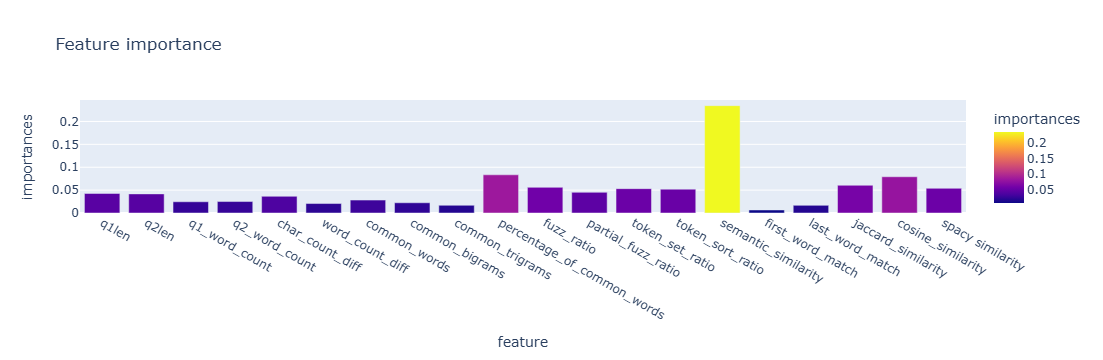

In [158]:
fig=px.bar(df_importances,x="feature",y="importances",title="Feature importance",color="importances",height=600)
fig.show()

## 10.Deep Learning modelling

In [161]:
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers

In [196]:
mdl=Sequential([
    layers.Input((20,)),
    layers.Dense(128,activation="relu"),
    layers.Dense(64,activation="relu"),
    layers.Dense(32,activation="relu"),
    layers.Dense(16,activation="relu"),
    layers.Dense(8,activation="relu"),
    layers.Dense(4,activation="relu"),
    layers.Dense(2,activation="relu"),
    layers.Dense(1,activation="sigmoid")
])
stop=tf.keras.callbacks.EarlyStopping(monitor="val_loss",min_delta=0.001,patience=3,restore_best_weights=True)
scheduler=tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss",factor=0.1,patience=2)
mdl.compile(optimizer=tf.keras.optimizers.AdamW(1e-2),loss=tf.keras.losses.BinaryCrossentropy(),metrics=["accuracy"])
hist=mdl.fit(x_train_scaled,y_train,epochs=20,batch_size=32,verbose=1,callbacks=[scheduler,stop],validation_split=0.1)

Epoch 1/20
9097/9097 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step - accuracy: 0.7845 - loss: 0.4532 - val_accuracy: 0.8026 - val_loss: 0.4073 - learning_rate: 0.0100
Epoch 2/20
9097/9097 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step - accuracy: 0.7994 - loss: 0.4076 - val_accuracy: 0.7990 - val_loss: 0.4074 - learning_rate: 0.0100
Epoch 3/20
9097/9097 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step - accuracy: 0.8002 - loss: 0.4074 - val_accuracy: 0.8048 - val_loss: 0.3984 - learning_rate: 0.0100
Epoch 4/20
9097/9097 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step - accuracy: 0.8025 - loss: 0.4024 - val_accuracy: 0.8062 - val_loss: 0.3984 - learning_rate: 0.0100
Epoch 5/20
9097/9097 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step - accuracy: 0.8010 - loss: 0.4016 - val_accuracy: 0.8004 - val_loss: 0.4035 - learning_rate: 0.0100
Epoch 6/20
9097/9097 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step - accuracy: 0.8069 - loss: 0.3912 - val_accuracy: 0.8093 - val_loss: 0.3861 - learning_rate: 1.0000e-03
Epoch 7/20
9097/9097 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step - accuracy:

In [204]:
d={}
d["epoch"]=list(range(1,15))
for key in hist.history.keys():
    d["{}".format(key)]=hist.history["{}".format(key)]
print(d)

{'epoch': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14], 'accuracy': [0.7930660247802734, 0.79808509349823, 0.8011151552200317, 0.8031660318374634, 0.8002116084098816, 0.8087313771247864, 0.8109163045883179, 0.8115999102592468, 0.8125103116035461, 0.8129912614822388, 0.8137916922569275, 0.814963161945343, 0.8156227469444275, 0.8162686228752136], 'loss': [0.4250750243663788, 0.41039589047431946, 0.40542367100715637, 0.4015696942806244, 0.40436530113220215, 0.3876649737358093, 0.38405847549438477, 0.38225364685058594, 0.3808300793170929, 0.3800570070743561, 0.37875255942344666, 0.37741386890411377, 0.3764026165008545, 0.3755914270877838], 'val_accuracy': [0.8026218414306641, 0.798973560333252, 0.8047860264778137, 0.8061773180961609, 0.8004266619682312, 0.809330940246582, 0.8113405704498291, 0.8086198568344116, 0.8126700520515442, 0.8085271120071411, 0.8128555417060852, 0.8131029009819031, 0.8135666847229004, 0.813535749912262], 'val_loss': [0.40725886821746826, 0.4073966145515442, 0.39

In [206]:
df=pd.DataFrame(data=d)
df

,epoch,accuracy,loss,val_accuracy,val_loss,learning_rate
0,1,0.793066,0.425075,0.802622,0.407259,0.010
1,2,0.798085,0.410396,0.798974,0.407397,0.010
2,3,0.801115,0.405424,0.804786,0.398378,0.010
3,4,0.803166,0.401570,0.806177,0.398354,0.010
4,5,0.800212,0.404365,0.800427,0.403507,0.010
5,6,0.808731,0.387665,0.809331,0.386092,0.001
6,7,0.810916,0.384058,0.811341,0.384133,0.001
7,8,0.811600,0.382254,0.808620,0.384914,0.001
8,9,0.812510,0.380830,0.812670,0.381137,0.001
9,10,0.812991,0.380057,0.808527,0.382390,0.001


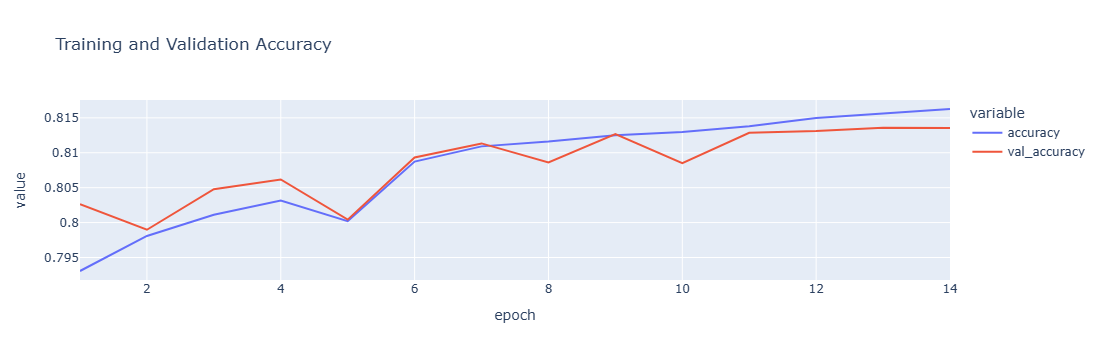

In [208]:
fig=px.line(df,x="epoch",y=["accuracy","val_accuracy"],title="Training and Validation Accuracy")
fig.show()

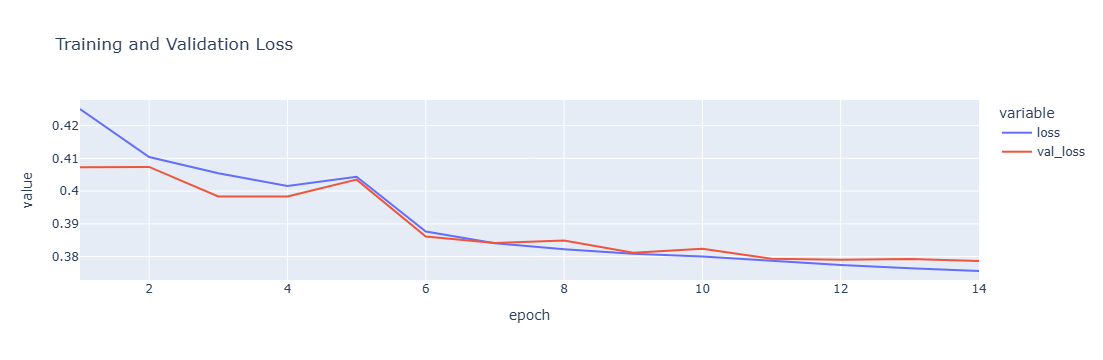

In [210]:
fig=px.line(df,x="epoch",y=["loss","val_loss"],title="Training and Validation Loss")
fig.show()

In [268]:
nn_pred=mdl.predict(x_test_scaled)

2527/2527 ━━━━━━━━━━━━━━━━━━━━ 1s 548us/step


In [269]:
nn_pred_df=pd.DataFrame(nn_pred,columns=["confidence"])
#nn_pred_df.rename(columns={"0":"confidence"})
nn_pred_df

,confidence
0,0.247345
1,0.008501
2,0.008501
3,0.642703
4,0.582293
...,...
80853,0.112963
80854,0.768426
80855,0.692193
80856,0.464106


## 11.A small observation

In [274]:
dupes_test=y_test.reset_index()
dupes_test.drop("index",axis=1,inplace=True)
confidence_test=pd.concat([x_test.iloc[:,:2],dupes_test,nn_pred_df],axis=1)
confidence_test

,question1,question2,is_duplicate,confidence
0,how do use 360 video website,how do use 360 video advertising,0,0.247345
1,which state india has number ias ips ifs toppers,people selected civil services ias ips irs ifs...,0,0.008501
2,what quickest way discharge battery,can elaborate details get interns iisc bangalo...,0,0.008501
3,what is best way lose calories fast,what is best way reduce weight fast,1,0.642703
4,is indian currency bill rs 2000 has gps chip t...,will rs 2000 currency note really come gps chi...,1,0.582293
...,...,...,...,...
80853,if logan k wolverine doesn age how did grow adult,how was wolverine “the wolverine 2013 ” able g...,0,0.112963
80854,what is easiest painless way commit suicide,what is painless way do suicide,1,0.768426
80855,which is overrated answer quora,which is overrated answer saw quora,1,0.692193
80856,how can become people person,how do become friendly person,1,0.464106


__Some questions seem to be very similar, our algorithm seems to have high confidence that they should be labeled as duplicates(1) but the label given is non duplicate(0).__

In [330]:
sqldf("SELECT * FROM confidence_test WHERE is_duplicate=0 AND confidence>0.7")

,question1,question2,is_duplicate,confidence
0,what does mean javascript,what does mean javascript,0,0.829267
1,how do cure myopia naturally,can myopia cured,0,0.746756
2,how can upload music youtube without getting c...,how can use music background music monetized y...,0,0.836472
3,if japan declared war ussr when germany did in...,if japan attacked ussr 1941 instead united sta...,0,0.902595
4,which is corrupt service upsc,which is least corrupt service upsc,0,0.823725
...,...,...,...,...
3655,does losing one five senses enhance others,does losing one five senses enhance others how,0,0.890315
3656,what is stupidest thing ever did,stupidity what is stupidest thing anyone has e...,0,0.746391
3657,research paper kinnow mandarin,research paper inm kinnow mandarin,0,0.827105
3658,how might go making own independent country,where should make own country,0,0.901279
